In [1]:
#connect to drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 920.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 59.1 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [3]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score, precision_score,recall_score,f1_score,roc_auc_score,roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import joblib

In [4]:
data_folder = "/content/drive/MyDrive/CIC_IDS2017/MachineLearningCVE"

if not os.path.exists(data_folder):
    raise FileNotFoundError(f"Folder '{data_folder}' not found. Please check the folder name.")

print("Using data folder:", data_folder)

Using data folder: /content/drive/MyDrive/CIC_IDS2017/MachineLearningCVE


In [5]:
csv_files = glob.glob(os.path.join(data_folder, "*.csv"))

print("Number of CSV files found:", len(csv_files))
for f in csv_files:
    print(os.path.basename(f))

Number of CSV files found: 8
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv


In [6]:
#combining files
df_list = []

for file in csv_files:
    try:
        temp_df = pd.read_csv(file, encoding='utf-8', low_memory=False)
        temp_df["source_file"] = os.path.basename(file)
        df_list.append(temp_df)
        print(f"Loaded: {os.path.basename(file)} -> {temp_df.shape}")
    except Exception as e:
        print(f"Error reading {file}: {e}")

df = pd.concat(df_list, ignore_index=True)
print("Combined shape:", df.shape)

Loaded: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv -> (225745, 80)
Loaded: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv -> (286467, 80)
Loaded: Friday-WorkingHours-Morning.pcap_ISCX.csv -> (191033, 80)
Loaded: Monday-WorkingHours.pcap_ISCX.csv -> (529918, 80)
Loaded: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv -> (288602, 80)
Loaded: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv -> (170366, 80)
Loaded: Tuesday-WorkingHours.pcap_ISCX.csv -> (445909, 80)
Loaded: Wednesday-workingHours.pcap_ISCX.csv -> (692703, 80)
Combined shape: (2830743, 80)


In [7]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 80 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

In [ ]:
df.shape

(2830743, 80)

In [ ]:
print("\nColumns:\n", df.columns.tolist())


Columns:
 [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', 

In [ ]:
df.isnull().sum()

,0
Destination Port,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
...,...
Idle Std,0
Idle Max,0
Idle Min,0
Label,0


In [ ]:
df.isnull().sum().sum()

np.int64(1358)

In [8]:
#remove spaces
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [9]:
if "Label" not in df.columns:
    raise ValueError("Column 'Label' not found.")

print(df["Label"].value_counts())

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [10]:
df["Label"] = df["Label"].astype(str).str.strip()
df["binary_label"] = df["Label"].apply(lambda x: 0 if x.upper() == "BENIGN" else 1)

df[["Label", "binary_label"]].head()

,Label,binary_label
0,BENIGN,0
1,BENIGN,0
2,BENIGN,0
3,BENIGN,0
4,BENIGN,0


In [ ]:
df["binary_label"].value_counts()

,count
binary_label,
0,2273097
1,557646


In [11]:
df.shape

(2830743, 81)

In [12]:
columns_to_drop = [
    "Destination Port",   #no need for port memroization, we focus on behaviour
    "Fwd Header Length.1",  #redundant info
    "source_file",      #identify the csv file
    "Label"    #no need , we will use binary_label
]

df = df.drop(columns=columns_to_drop)
df.shape

(2830743, 77)

In [13]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

missing_before = df.isnull().sum().sum()
print("Total missing values before handling:", missing_before)

Total missing values before handling: 5734


In [14]:
# drop rows with missing values
df.dropna(inplace=True)

In [15]:
df.isnull().sum().sum()

np.int64(0)

In [16]:
df.shape

(2827876, 77)

In [17]:
target_col = "binary_label"

feature_cols = [col for col in df.columns if col != target_col]

# convert to numeric
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [18]:
# checking for nulls again
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [19]:
df.shape

(2827876, 77)

array([[<Axes: title={'center': 'Flow Duration'}>,
        <Axes: title={'center': 'Total Fwd Packets'}>,
        <Axes: title={'center': 'Total Backward Packets'}>,
        <Axes: title={'center': 'Total Length of Fwd Packets'}>,
        <Axes: title={'center': 'Total Length of Bwd Packets'}>,
        <Axes: title={'center': 'Fwd Packet Length Max'}>,
        <Axes: title={'center': 'Fwd Packet Length Min'}>,
        <Axes: title={'center': 'Fwd Packet Length Mean'}>,
        <Axes: title={'center': 'Fwd Packet Length Std'}>],
       [<Axes: title={'center': 'Bwd Packet Length Max'}>,
        <Axes: title={'center': 'Bwd Packet Length Min'}>,
        <Axes: title={'center': 'Bwd Packet Length Mean'}>,
        <Axes: title={'center': 'Bwd Packet Length Std'}>,
        <Axes: title={'center': 'Flow Bytes/s'}>,
        <Axes: title={'center': 'Flow Packets/s'}>,
        <Axes: title={'center': 'Flow IAT Mean'}>,
        <Axes: title={'center': 'Flow IAT Std'}>,
        <Axes: title={'cen

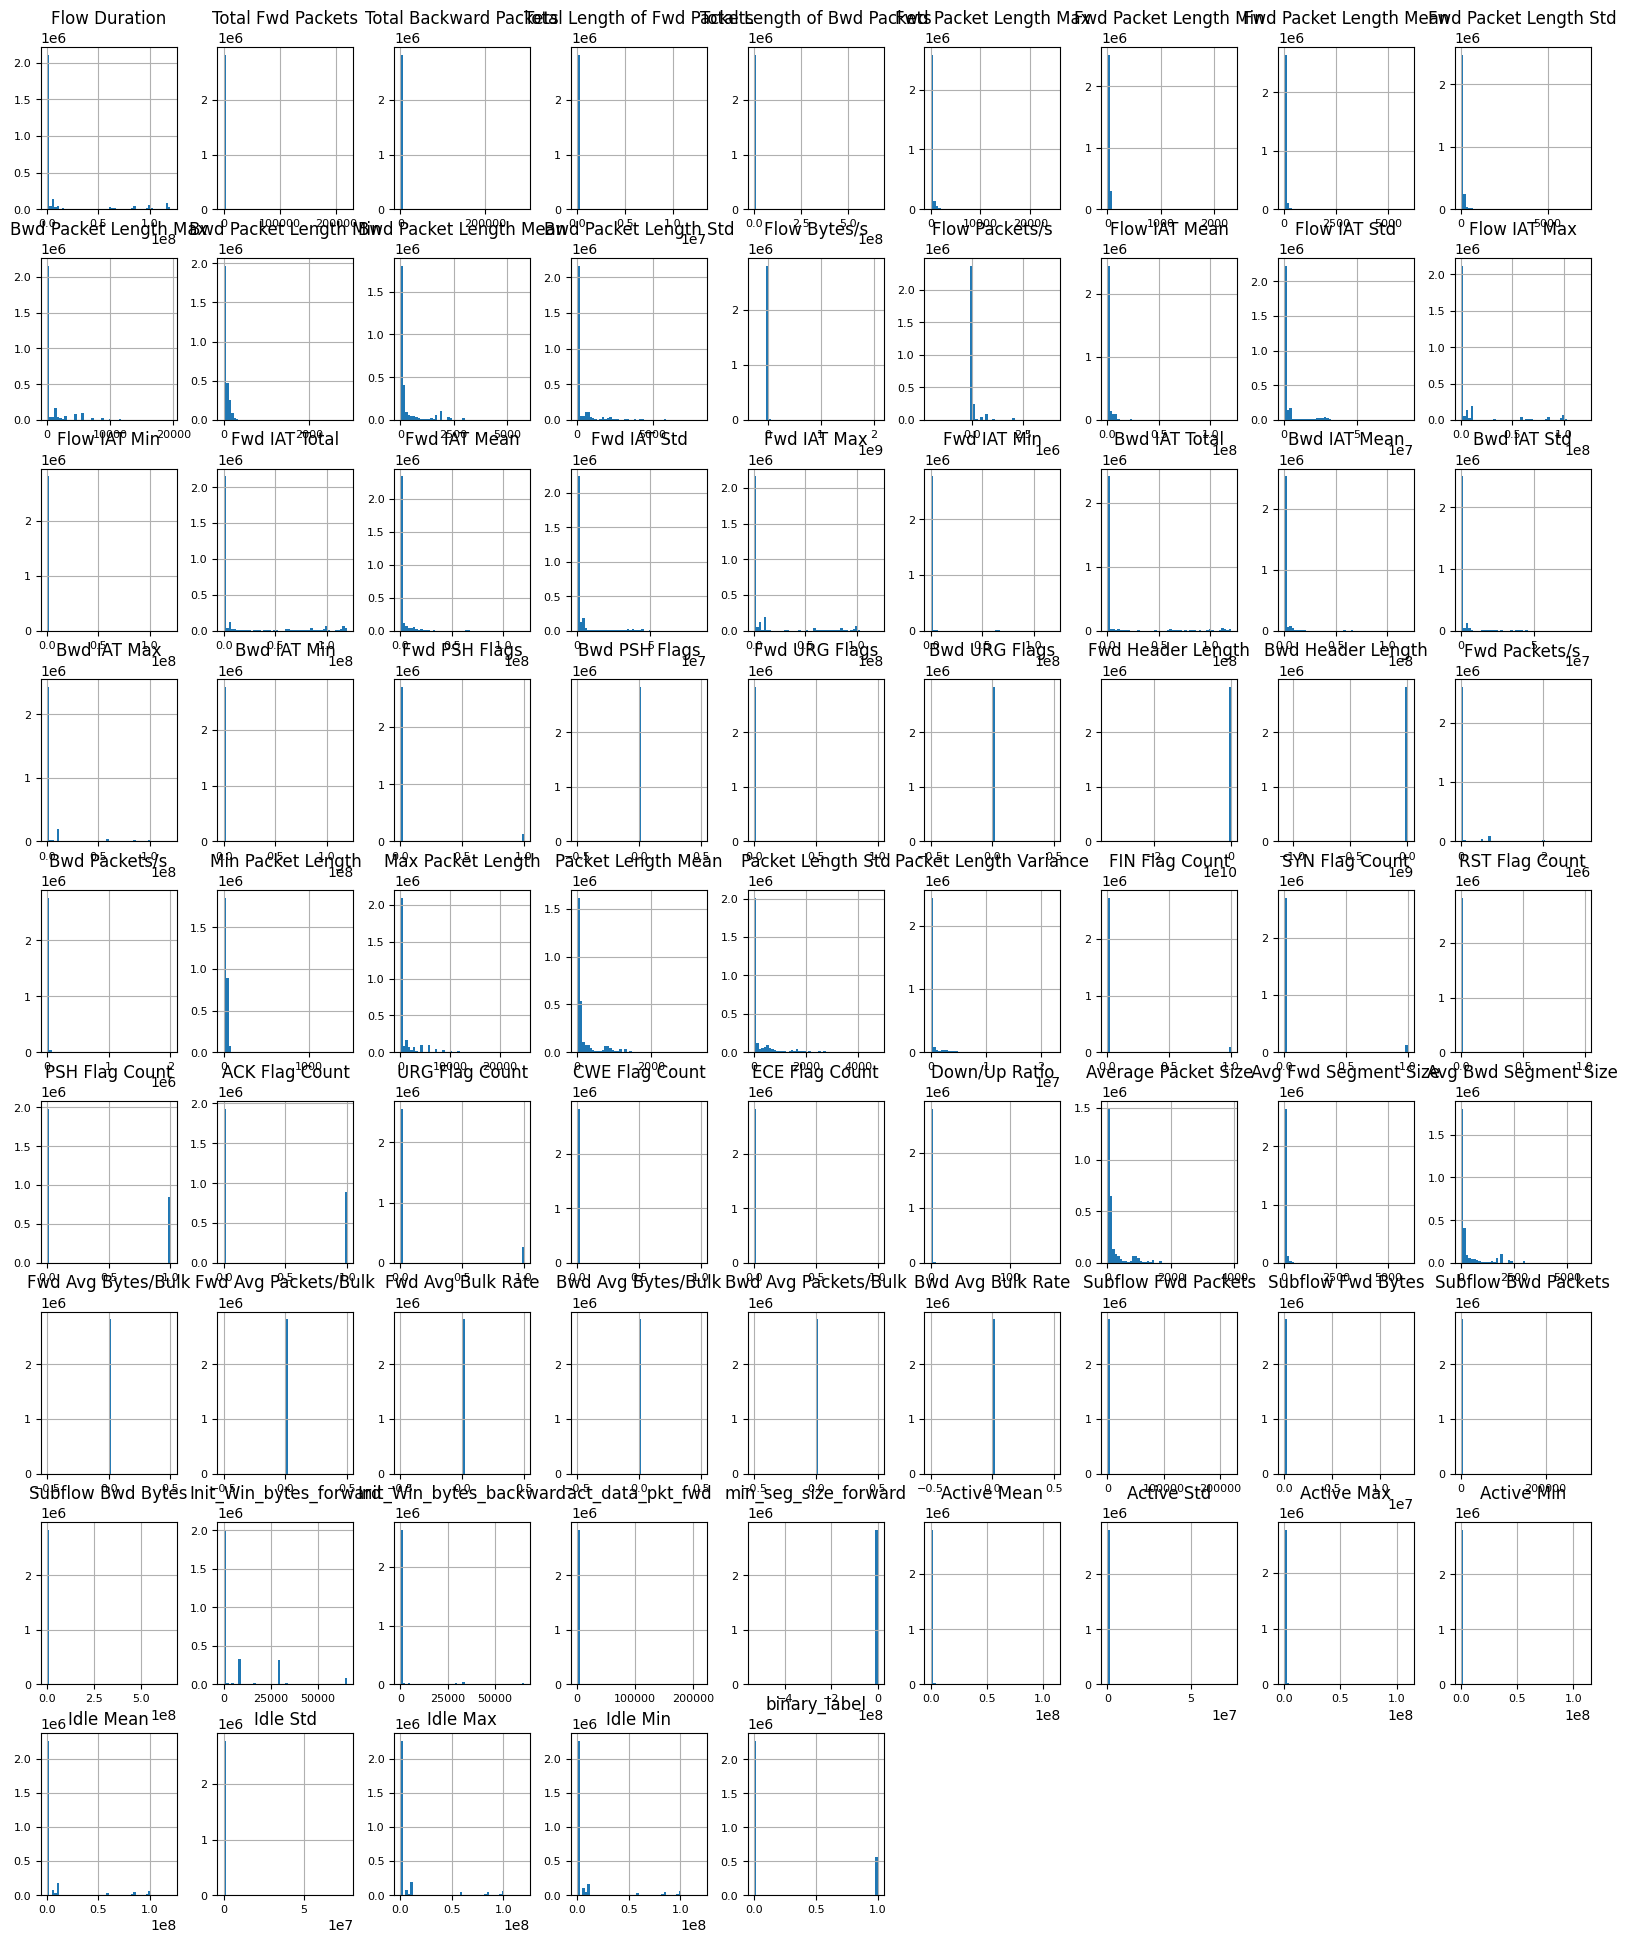

In [ ]:
#showing columns frequencies
df.hist(figsize=(20,24), bins=50, xlabelsize=8, ylabelsize=8)

In [ ]:
#let's see data skewness
df.skew(numeric_only=True)

,0
Flow Duration,2.153647
Total Fwd Packets,244.256775
Total Backward Packets,244.555577
Total Length of Fwd Packets,805.165955
Total Length of Bwd Packets,244.207129
...,...
Idle Mean,3.063487
Idle Std,10.487948
Idle Max,2.949327
Idle Min,3.182483


Text(0.5, 1.0, 'label Distribution')

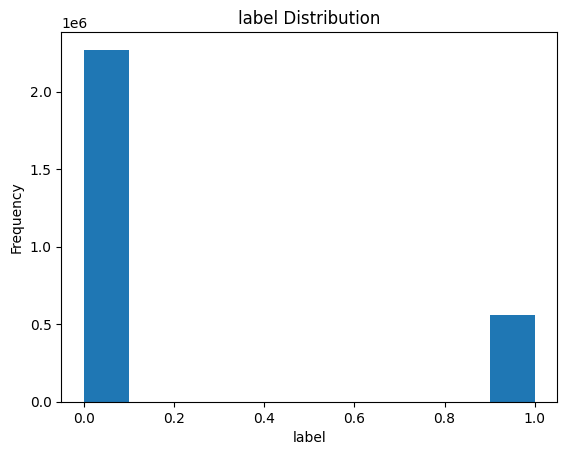

In [ ]:
plt.hist(df['binary_label'])
plt.xlabel('label')
plt.ylabel('Frequency')
plt.title('label Distribution')

<Axes: >

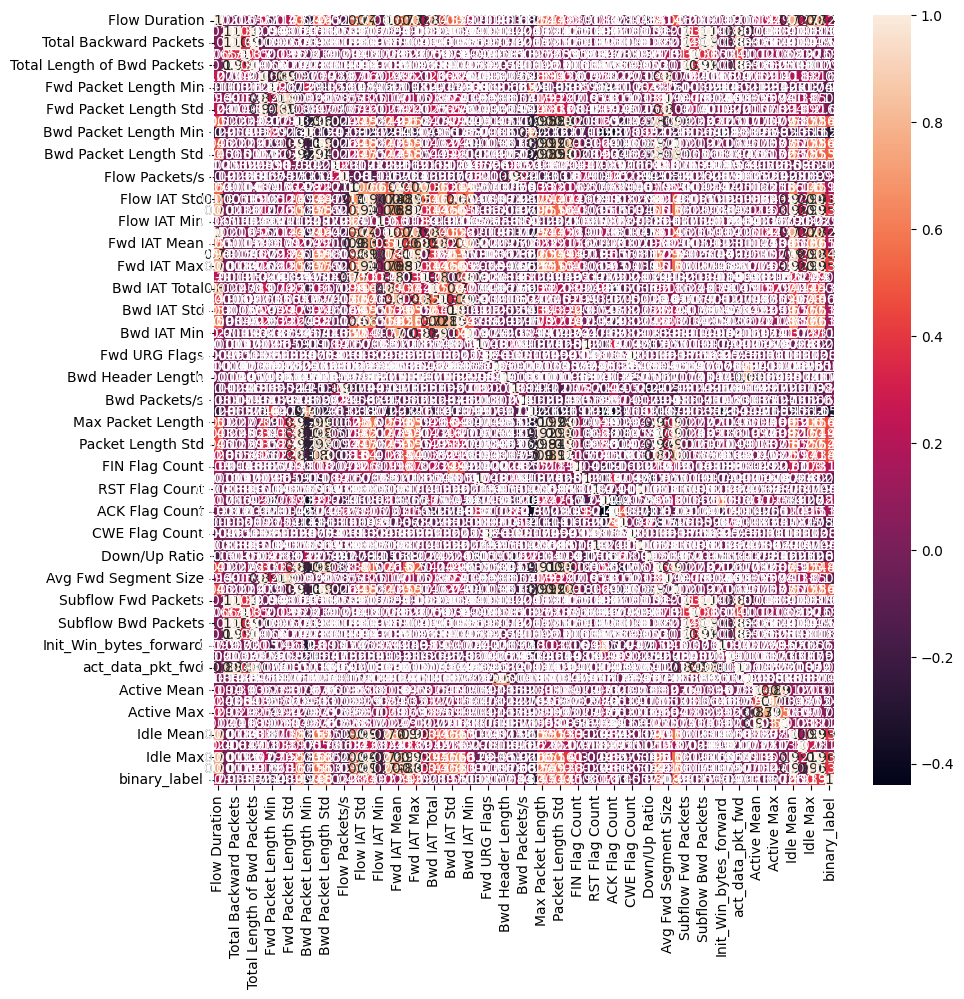

In [ ]:
#heat map
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot=True)

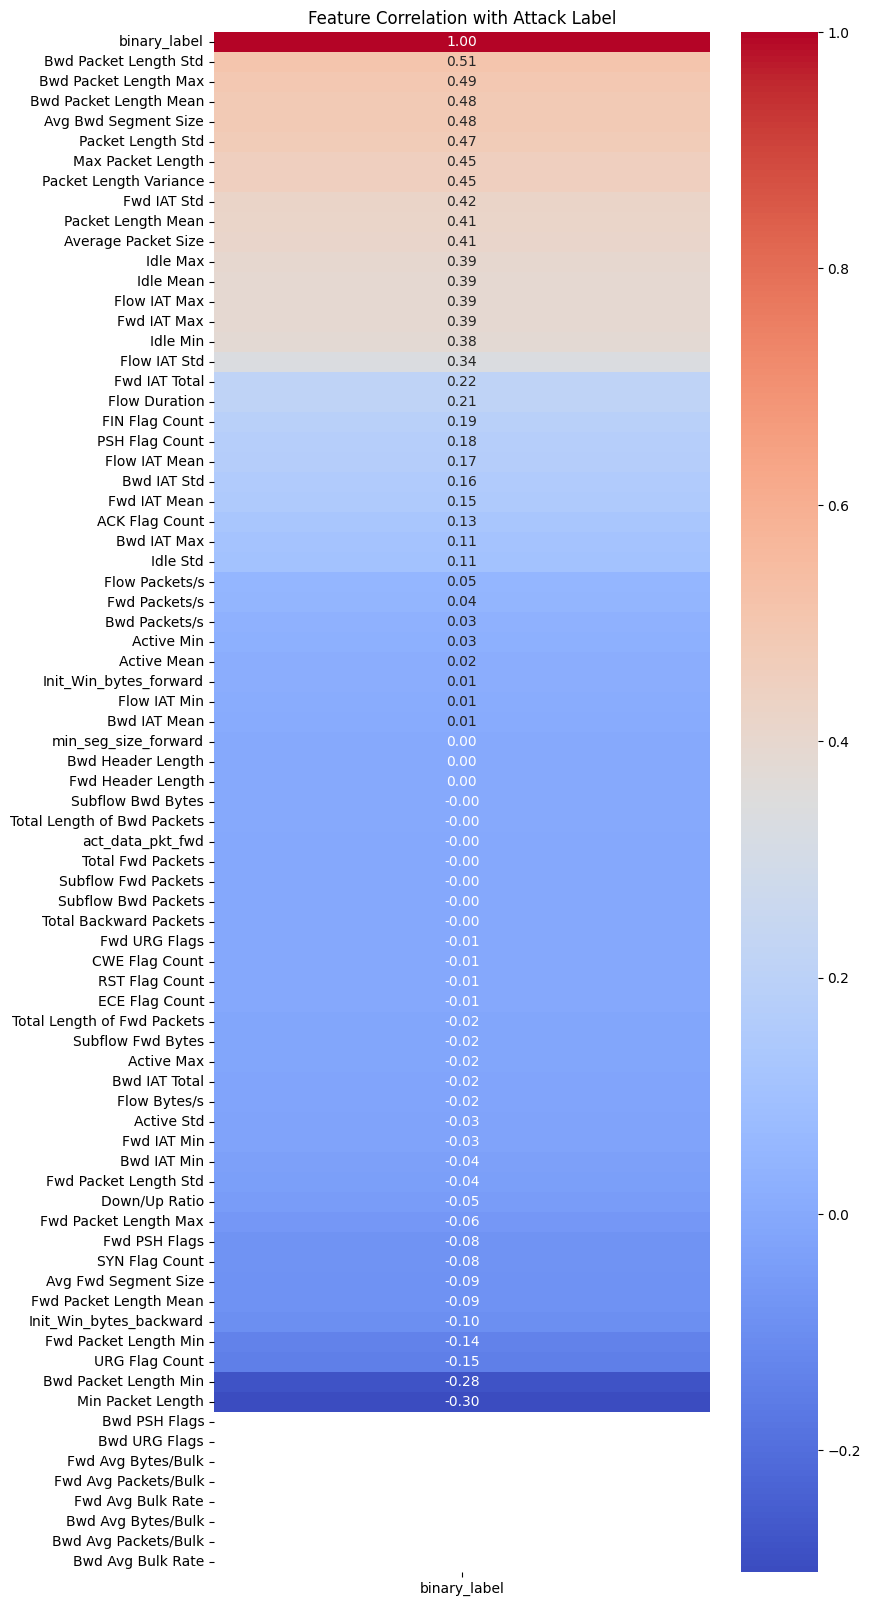

In [ ]:
#to understand the heatmap clearly by showing correlations to the target column only
plt.figure(figsize=(8, 20))
# calculate correlation and sort by the target column
target_corr = df.corr()[['binary_label']].sort_values(by='binary_label', ascending=False)

sns.heatmap(target_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation with Attack Label')
plt.show()

In [21]:
#understanding blanks in heatmap
blank_corr_cols = target_corr[target_corr['binary_label'].isna()]
print(blank_corr_cols)

for col in blank_corr_cols.index:
    print(f"\nColumn: {col}")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head())

                      binary_label
Bwd PSH Flags                  NaN
Bwd URG Flags                  NaN
Fwd Avg Bytes/Bulk             NaN
Fwd Avg Packets/Bulk           NaN
Fwd Avg Bulk Rate              NaN
Bwd Avg Bytes/Bulk             NaN
Bwd Avg Packets/Bulk           NaN
Bwd Avg Bulk Rate              NaN

Column: Bwd PSH Flags
Unique values: 1
Bwd PSH Flags
0    2827876
Name: count, dtype: int64

Column: Bwd URG Flags
Unique values: 1
Bwd URG Flags
0    2827876
Name: count, dtype: int64

Column: Fwd Avg Bytes/Bulk
Unique values: 1
Fwd Avg Bytes/Bulk
0    2827876
Name: count, dtype: int64

Column: Fwd Avg Packets/Bulk
Unique values: 1
Fwd Avg Packets/Bulk
0    2827876
Name: count, dtype: int64

Column: Fwd Avg Bulk Rate
Unique values: 1
Fwd Avg Bulk Rate
0    2827876
Name: count, dtype: int64

Column: Bwd Avg Bytes/Bulk
Unique values: 1
Bwd Avg Bytes/Bulk
0    2827876
Name: count, dtype: int64

Column: Bwd Avg Packets/Bulk
Unique values: 1
Bwd Avg Packets/Bulk
0    2827876
Name

Constant columns: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


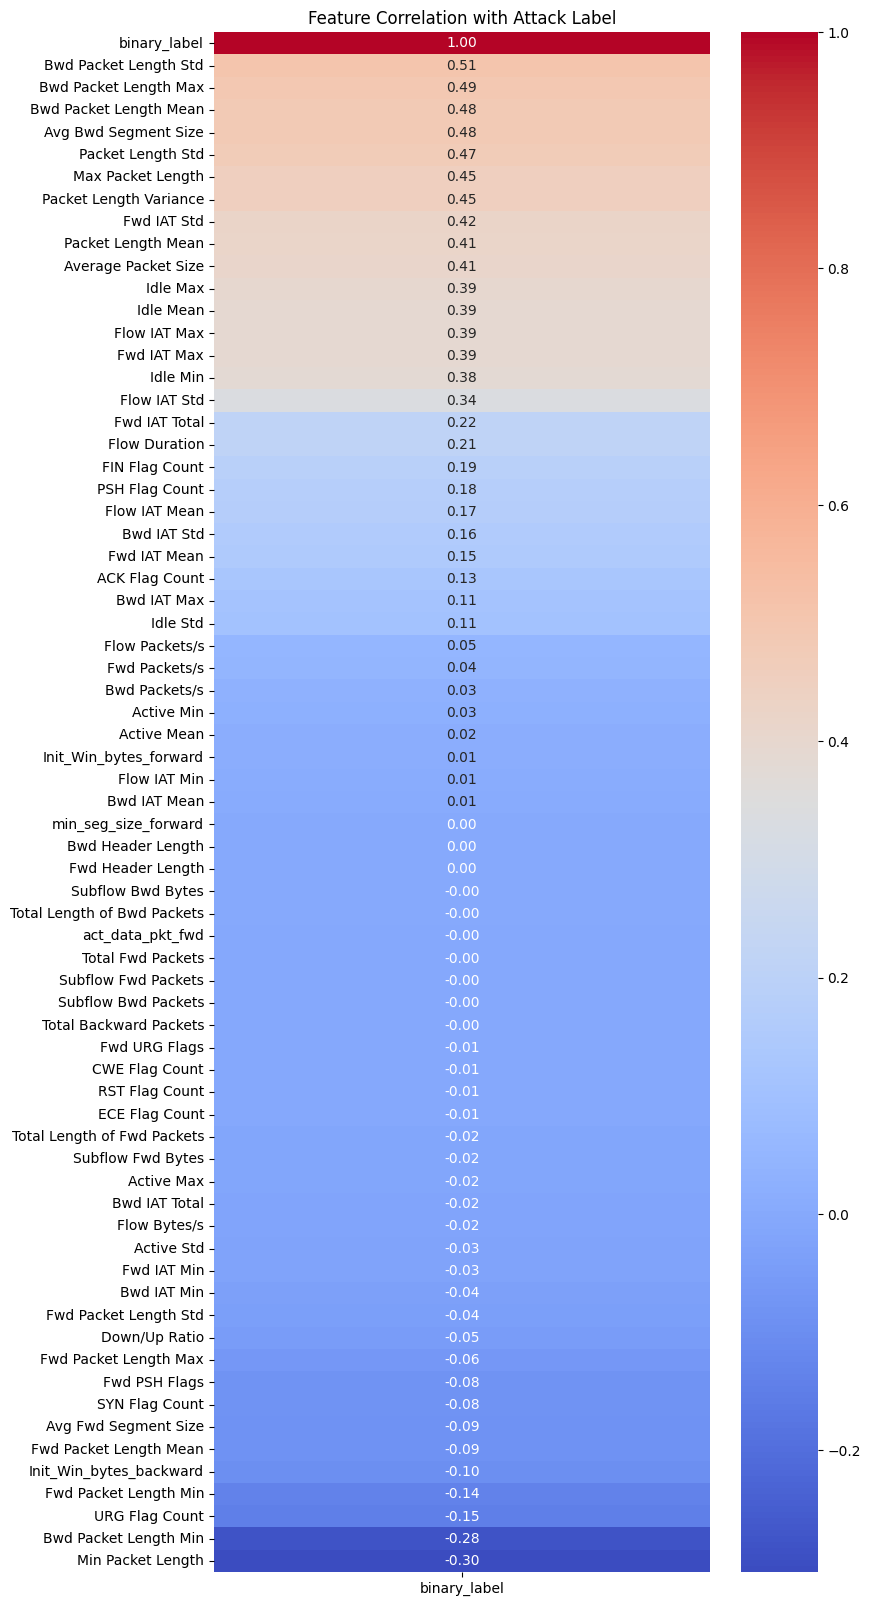

In [22]:
# remove constant columns as they don't provide any info to the model
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print("Constant columns:", constant_cols)

df = df.drop(columns=constant_cols)

plt.figure(figsize=(8, 20))
target_corr = df.corr(numeric_only=True)[['binary_label']].sort_values(by='binary_label', ascending=False)
sns.heatmap(target_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation with Attack Label')
plt.show()

In [23]:
df.shape

(2827876, 69)

In [ ]:
#create data2 instead of messing with the original data variable to perform IQR and see what happens
data2 = df.copy()

In [ ]:
data2.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,binary_label
0,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,109,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,52,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,34,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0


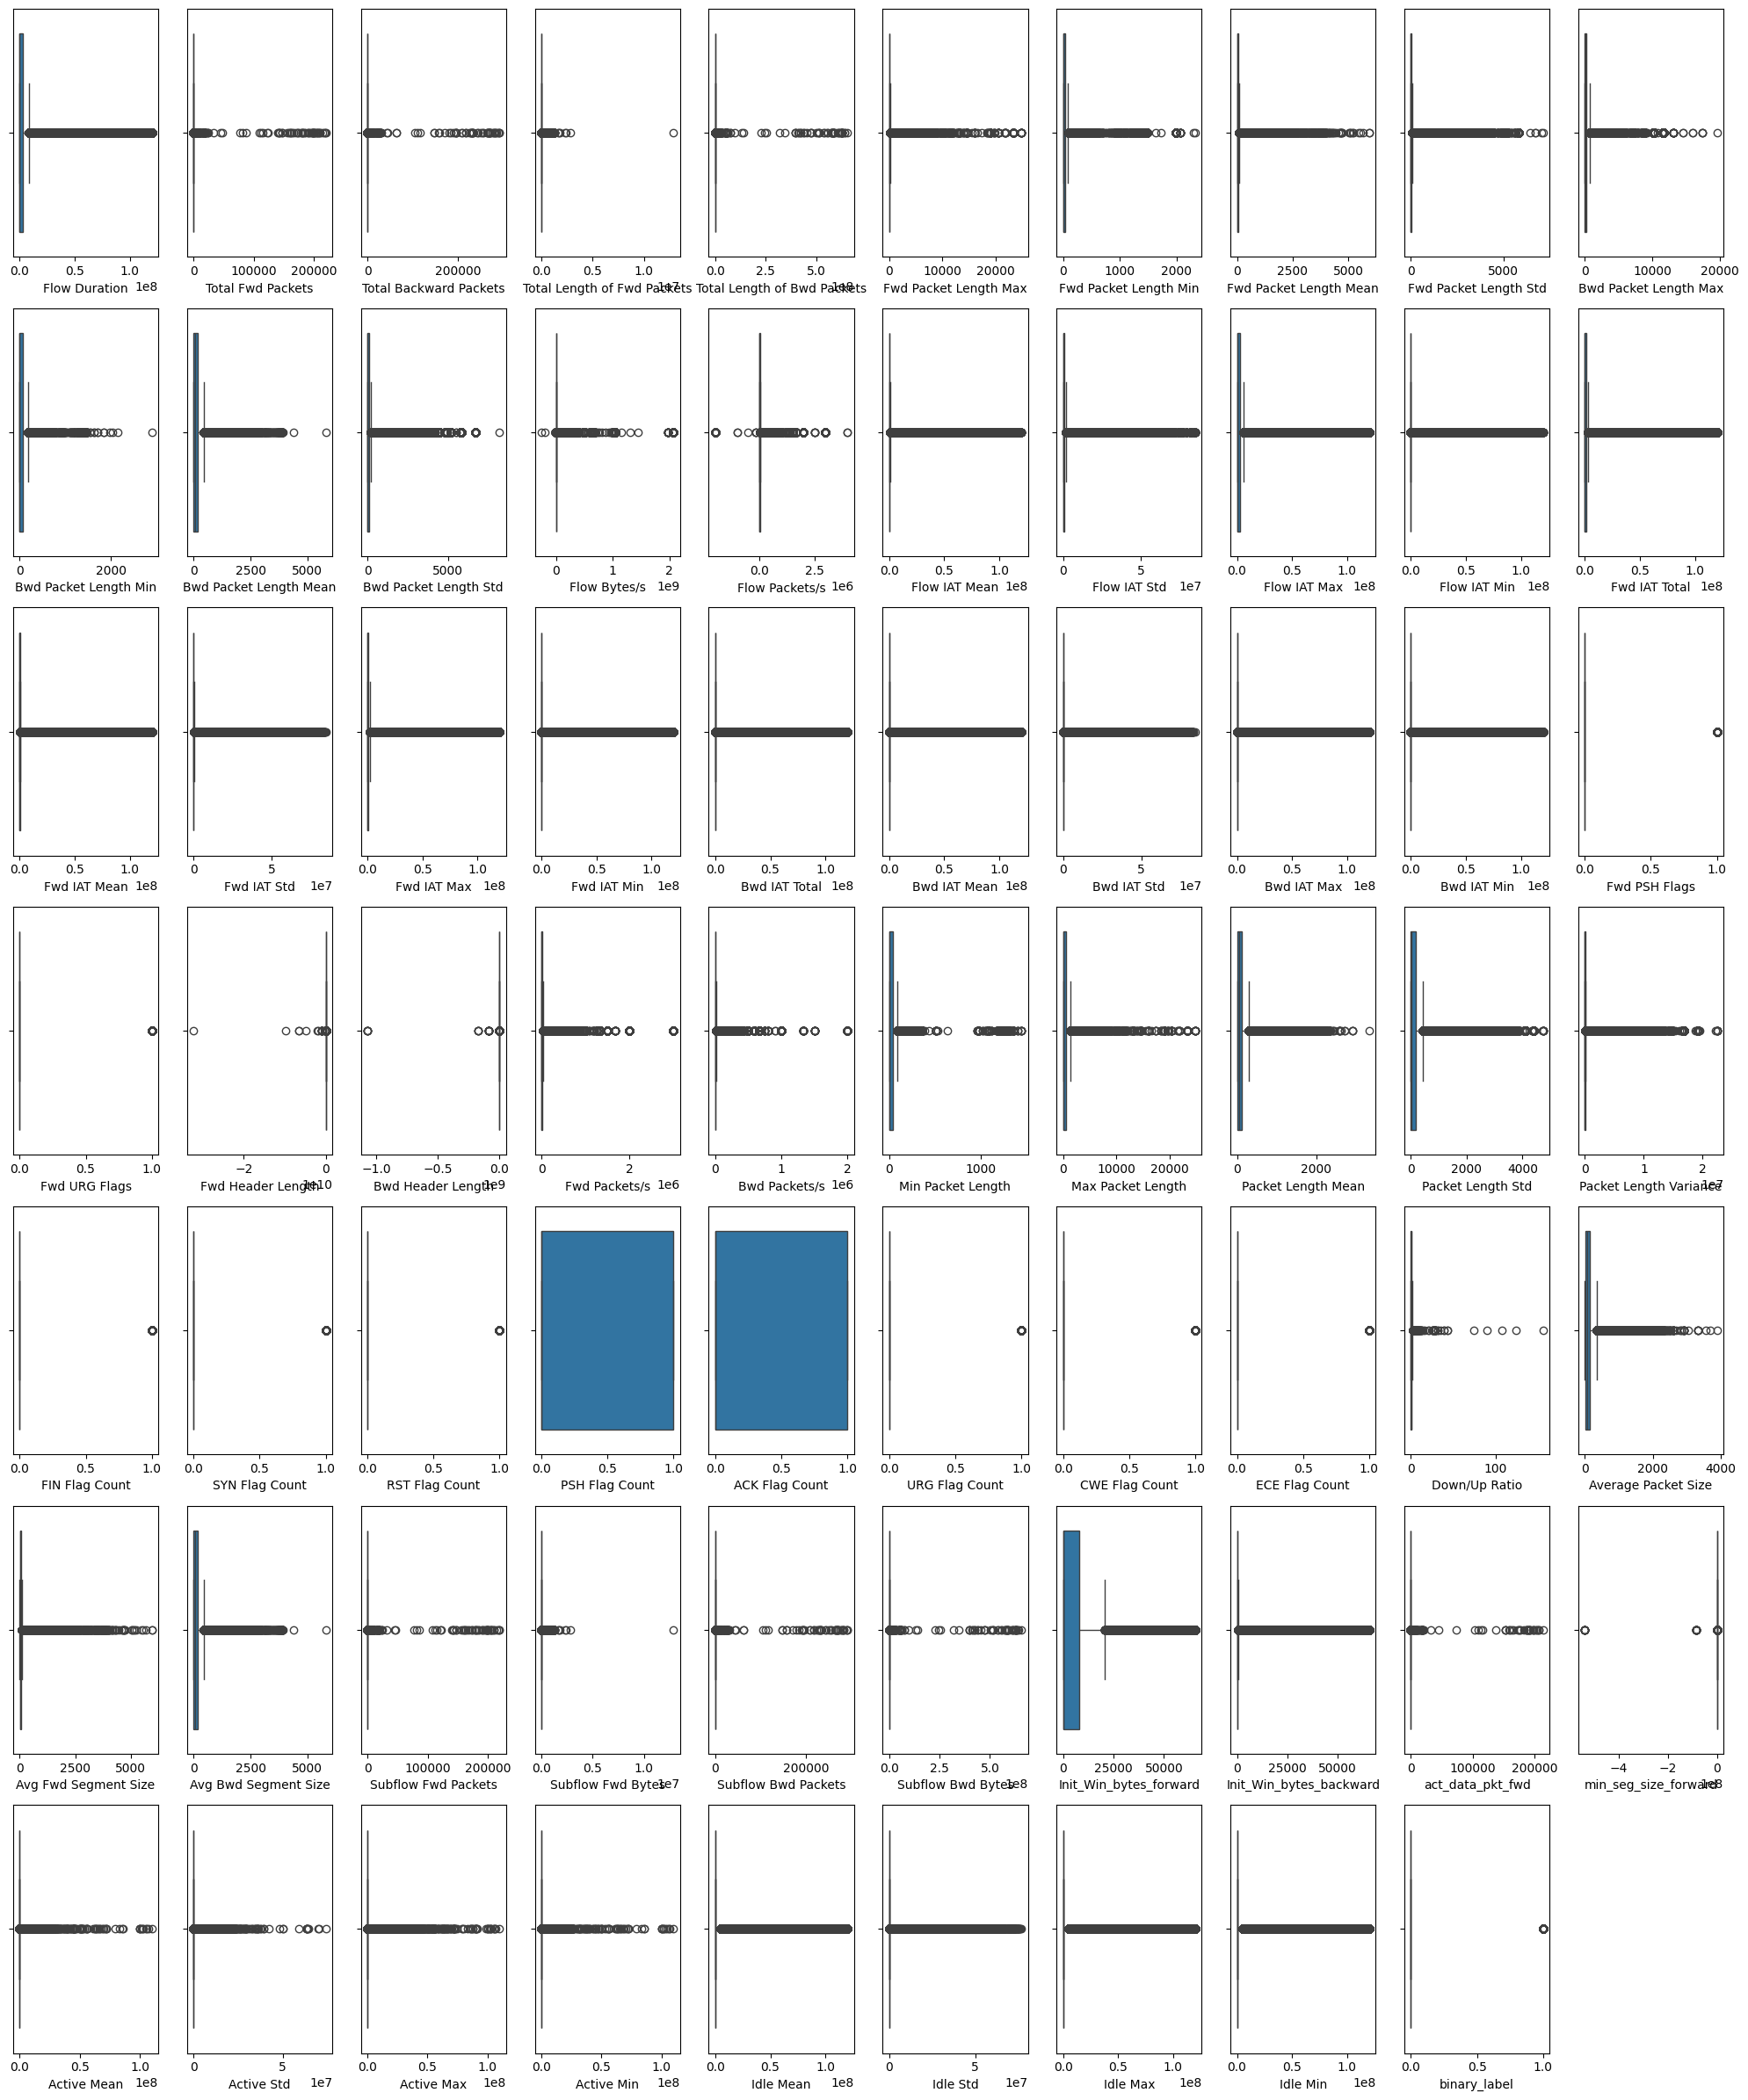

In [ ]:
#Identify any anomalies or outliers in the data
fig = plt.figure(figsize=(20, 24))
num_columns = len(data2.columns)
n_rows = (num_columns + 9) // 10  # number of rows needed to get 10 figures for each row (9 is a trick to force round up if needed)

for i in range(num_columns):
  plt.subplot(n_rows, 10, i+1)
  sns.boxplot(x=data2[data2.columns[i]])
plt.tight_layout()

In [ ]:
data2.shape

(2827876, 69)

In [ ]:
#remove any outliers in data
for column in data2.columns:
    Q3 = data2[column].quantile(.75)
    Q1 = data2[column].quantile(.25)
    IQR = Q3 - Q1
    upper_limit = Q3 + (1.5*IQR)
    lower_limit = Q1 - (1.5*IQR)
    data2.drop(data2[data2[column] > upper_limit].index, inplace=True)
    data2.drop(data2[data2[column] < lower_limit].index, inplace=True)

In [ ]:
data2.shape

(200353, 69)

In [ ]:
'''data reduced from 2827876 to 200353 (93% of the data removed) which is incorrect and probably
    removed the attack label as attacks supposed to be outliers
    so I will discard data2 and return befores outlier removal'''

'data reduced from 2827876 to 200353 (93% of the data removed) which is incorrect and probably\n    removed the attack label as attacks supposed to be outliers\n    so I will discard data2 and return befores outlier removal'

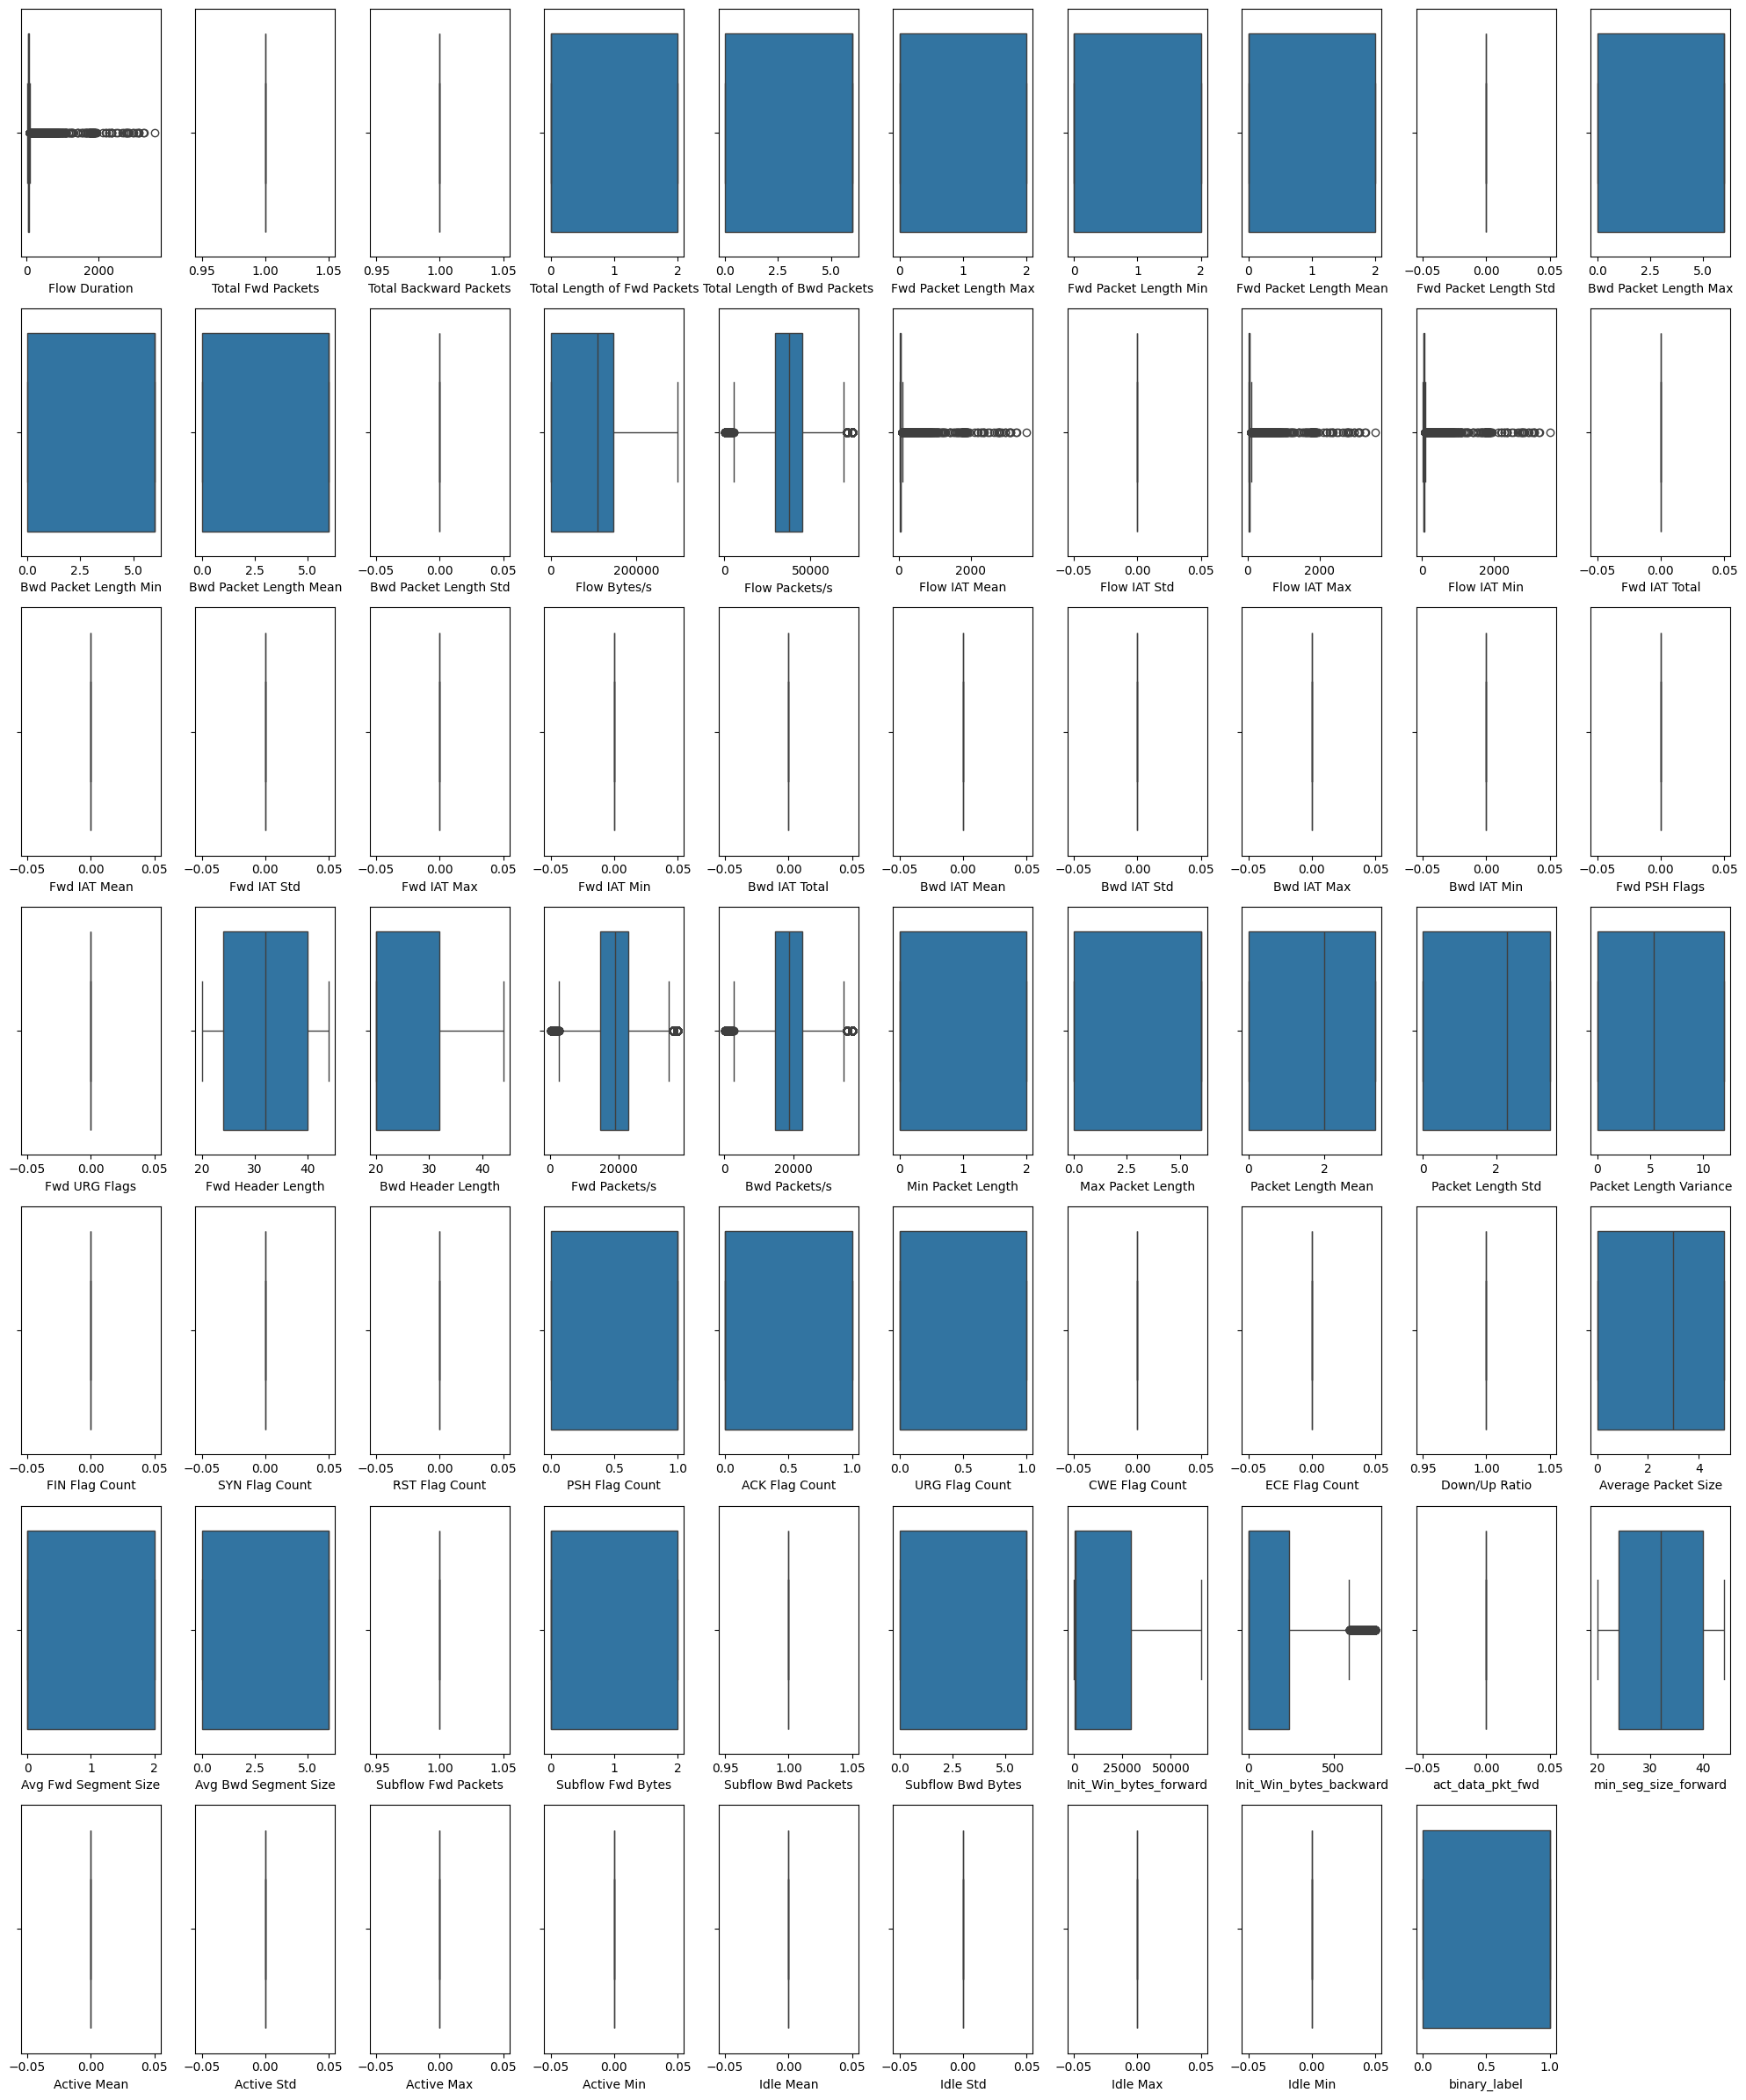

In [ ]:
#Identify any anomalies or outliers in the data
fig = plt.figure(figsize=(20, 24))
num_columns = len(data2.columns)
n_rows = (num_columns + 9) // 10  # number of rows needed (cieled)

for i in range(num_columns):
  plt.subplot(n_rows, 10, i+1)
  sns.boxplot(x=data2[data2.columns[i]])
plt.tight_layout()

Text(0.5, 1.0, 'label Distribution')

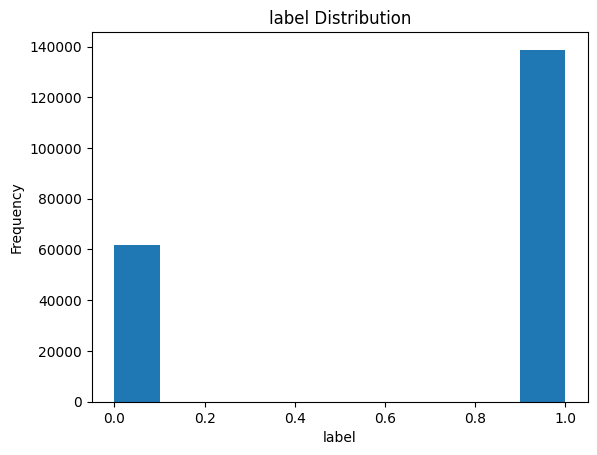

In [ ]:
plt.hist(data2['binary_label'])
plt.xlabel('label')
plt.ylabel('Frequency')
plt.title('label Distribution')

In [24]:
#the original data variable
df.shape

(2827876, 69)

In [25]:
x = df.drop(['binary_label'], axis=1)
y = df['binary_label']

In [26]:
from sklearn.model_selection import train_test_split

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=100, stratify=y)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(2403694, 68)
(424182, 68)
(2403694,)
(424182,)


In [ ]:
y_train.value_counts()

,count
binary_label,
0,1930622
1,473072


In [ ]:
y_test.value_counts()

,count
binary_label,
0,340698
1,83484


In [27]:
#scale feature
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
#implement logistic regression
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(x_train_scaled, y_train)

LogisticRegression()

In [ ]:
#calculate y_pred and accuracy
y_pred = logreg.predict(x_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9242282793706476


In [ ]:
#confusion matrix , recall , precesion and f1 score
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[327665  13033]
 [ 19108  64376]]
              precision    recall  f1-score   support

           0       0.94      0.96      0.95    340698
           1       0.83      0.77      0.80     83484

    accuracy                           0.92    424182
   macro avg       0.89      0.87      0.88    424182
weighted avg       0.92      0.92      0.92    424182



In [ ]:
#random forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train_scaled, y_train)

RandomForestClassifier()

In [ ]:
#calculate y_pred and accuracy
y_pred = rf.predict(x_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.998924989744968


In [ ]:
#confusion matrix , recall , precesion and f1 score
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[340403    295]
 [   161  83323]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    340698
           1       1.00      1.00      1.00     83484

    accuracy                           1.00    424182
   macro avg       1.00      1.00      1.00    424182
weighted avg       1.00      1.00      1.00    424182



In [ ]:
#random forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 50 , max_depth = 30)
rf.fit(x_train_scaled, y_train)

RandomForestClassifier(max_depth=30, n_estimators=50)

In [ ]:
#calculate y_pred and accuracy
y_pred = rf.predict(x_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9989179173090796


In [ ]:
#confusion matrix , recall , precesion and f1 score
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[340405    293]
 [   166  83318]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    340698
           1       1.00      1.00      1.00     83484

    accuracy                           1.00    424182
   macro avg       1.00      1.00      1.00    424182
weighted avg       1.00      1.00      1.00    424182



In [ ]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 1.3 MB/s eta 0:00:00


In [ ]:
#XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators = 10)
xgb.fit(x_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=10,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#calculate y_pred and accuracy
y_pred = xgb.predict(x_test_scaled)
accuracy = accuracy_score(y_test,  y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9957353211593137


In [ ]:
#confusion matrix , recall , precesion and f1 score
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[339777    921]
 [   888  82596]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    340698
           1       0.99      0.99      0.99     83484

    accuracy                           1.00    424182
   macro avg       0.99      0.99      0.99    424182
weighted avg       1.00      1.00      1.00    424182



In [ ]:
#XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators = 50)
xgb.fit(x_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#calculate y_pred and accuracy
y_pred = xgb.predict(x_test_scaled)
accuracy = accuracy_score(y_test,  y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9988943425227851


In [ ]:
#confusion matrix , recall , precesion and f1 score
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[340385    313]
 [   156  83328]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    340698
           1       1.00      1.00      1.00     83484

    accuracy                           1.00    424182
   macro avg       1.00      1.00      1.00    424182
weighted avg       1.00      1.00      1.00    424182



In [28]:
x_val, x_test_, y_val, y_test_ = train_test_split(x_test, y_test,test_size=0.60,random_state=42,stratify=y_test)

In [29]:
print(x_val.shape)
print(x_test_.shape)
print(y_val.shape)
print(y_test_.shape)

(169672, 68)
(254510, 68)
(169672,)
(254510,)


In [30]:
#scale x_val and x_test_ for DL
x_val_scaled = scaler.transform(x_val)
x_test_final_scaled = scaler.transform(x_test_)

print("x_train_scaled shape:", x_train_scaled.shape)
print("x_val_scaled shape:", x_val_scaled.shape)
print("x_test_final_scaled shape:", x_test_final_scaled.shape)

x_train_scaled shape: (2403694, 68)
x_val_scaled shape: (169672, 68)
x_test_final_scaled shape: (254510, 68)


In [31]:
#for class imbalance we computer weights to give the minority class more importance
#we make sure that DL won't bias towards the majority class
classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight='balanced',    #to give minority weights higher than majority
    classes=classes,
    y=y_train
)

class_weights = {int(c): w for c, w in zip(classes, class_weights_array)} #pairing each class with the needed weight
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.6225180278687387), 1: np.float64(2.540516031386343)}


In [32]:
#for model performance stability
early_stop = EarlyStopping(
    monitor='val_loss',  # for model performance on unseen data
    patience=5,
    restore_best_weights=True,
    verbose=1)
#reduce the LR when model starts to slow down to reduce overfitting
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,   #multiply LR by 0.5
    patience=2,
    min_lr=1e-6,    #prevent reduce under 0.000001
    verbose=1)

In [ ]:
dl_model_1 = Sequential([
    Input(shape=(x_train_scaled.shape[1],)),
    #L2 helps improve generalization (for large wieghts to make it a little smaller)
    #if L2 is higher than that , underfitting would become an issue
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    #randomly shuttin down 30% of neurons to reduce over fitting
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])
dl_model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,497 (228.50 KB)

 Trainable params: 58,497 (228.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
dl_model_1.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history_1 = dl_model_1.fit(
    x_train_scaled, y_train,
    validation_data=(x_val_scaled, y_val),
    epochs=25,
    batch_size=1024,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1)

Epoch 1/25
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9535 - loss: 0.1888 - val_accuracy: 0.9592 - val_loss: 0.1451 - learning_rate: 0.0010
Epoch 2/25
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9609 - loss: 0.1166 - val_accuracy: 0.9623 - val_loss: 0.1178 - learning_rate: 0.0010
Epoch 3/25
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9615 - loss: 0.1082 - val_accuracy: 0.9645 - val_loss: 0.1016 - learning_rate: 0.0010
Epoch 4/25
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9624 - loss: 0.1031 - val_accuracy: 0.9615 - val_loss: 0.1069 - learning_rate: 0.0010
Epoch 5/25
2331/2348 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9623 - loss: 0.1014
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9625 - loss: 0.1006 - val_accuracy: 0.9612 - val_loss: 0.1060 - learning_rate: 0.0010
Epoch 6/25
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.964

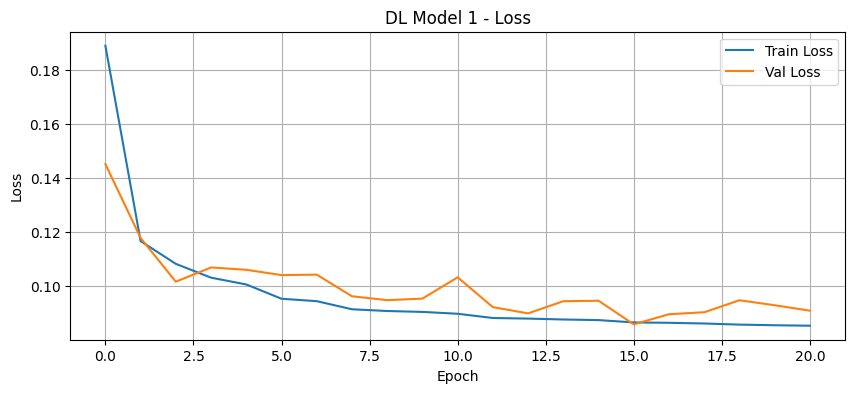

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(history_1.history['loss'], label='Train Loss')
plt.plot(history_1.history['val_loss'], label='Val Loss')
plt.title('DL Model 1 - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

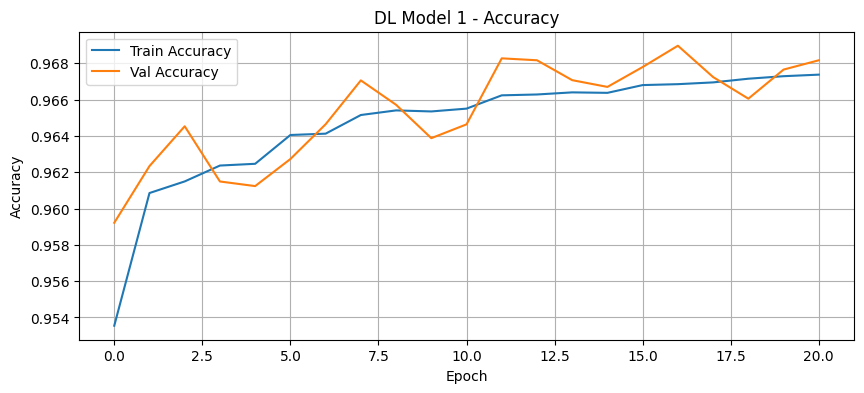

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(history_1.history['accuracy'], label='Train Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Val Accuracy')
plt.title('DL Model 1 - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
y_prob_1 = dl_model_1.predict(x_test_final_scaled).ravel()
y_pred_1 = (y_prob_1 >= 0.5).astype(int)

print("DL Model 1 Accuracy:", accuracy_score(y_test_, y_pred_1))
#Receiver Operating Characteristic to check performance under more thresholds not just 0.5
#high ROC means the model knows the differnce between classes vert well
print("DL Model 1 ROC-AUC :", roc_auc_score(y_test_, y_prob_1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_, y_pred_1))
print("\nClassification Report:\n", classification_report(y_test_, y_pred_1))

7954/7954 ━━━━━━━━━━━━━━━━━━━━ 4s 538us/step
DL Model 1 Accuracy: 0.9679148167066127
DL Model 1 ROC-AUC : 0.9964174007771195

Confusion Matrix:
 [[197143   7276]
 [   890  49201]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98    204419
           1       0.87      0.98      0.92     50091

    accuracy                           0.97    254510
   macro avg       0.93      0.97      0.95    254510
weighted avg       0.97      0.97      0.97    254510



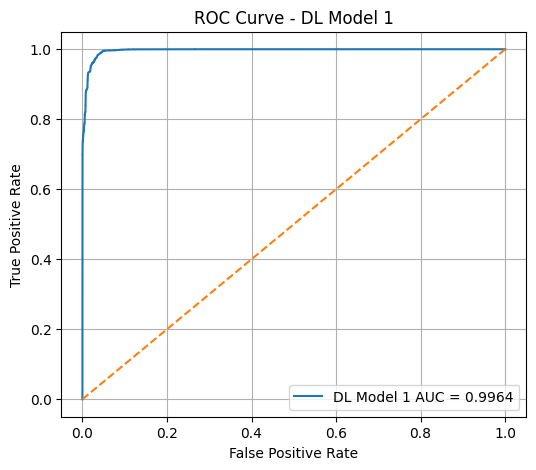

In [ ]:
#fpr-> false positive rate , tpr-> recall, _ -> thresholds
fpr1, tpr1, _ = roc_curve(y_test_, y_prob_1)

plt.figure(figsize=(6,5))
plt.plot(fpr1, tpr1, label=f'DL Model 1 AUC = {roc_auc_score(y_test_, y_prob_1):.4f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DL Model 1")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
dl_model_2 = Sequential([
    Input(shape=(x_train_scaled.shape[1],)),

    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),   #normalizing output for better behaviour
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

dl_model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,721 (245.00 KB)

 Trainable params: 61,825 (241.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [34]:
dl_model_2.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [35]:
history_2 = dl_model_2.fit(
    x_train_scaled, y_train,
    validation_data=(x_val_scaled, y_val),
    epochs=25,
    batch_size=1024,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/25
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.9445 - loss: 0.2079 - val_accuracy: 0.9591 - val_loss: 0.1137 - learning_rate: 0.0010
Epoch 2/25
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.9550 - loss: 0.1188 - val_accuracy: 0.9590 - val_loss: 0.1107 - learning_rate: 0.0010
Epoch 3/25
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.9557 - loss: 0.1150 - val_accuracy: 0.9598 - val_loss: 0.1088 - learning_rate: 0.0010
Epoch 4/25
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.9564 - loss: 0.1129 - val_accuracy: 0.9611 - val_loss: 0.1063 - learning_rate: 0.0010
Epoch 5/25
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.9565 - loss: 0.1108 - val_accuracy: 0.9625 - val_loss: 0.1023 - learning_rate: 0.0010
Epoch 6/25
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.9569 - loss: 0.1091 - val_accuracy: 0.9609 - val_loss: 0.1077 - learning_rate: 0.0010
Epoch 7/25
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accura

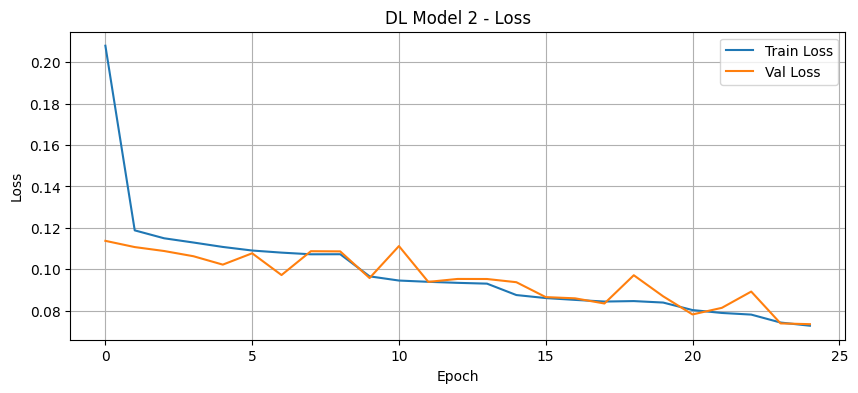

In [36]:
plt.figure(figsize=(10,4))
plt.plot(history_2.history['loss'], label='Train Loss')
plt.plot(history_2.history['val_loss'], label='Val Loss')
plt.title('DL Model 2 - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

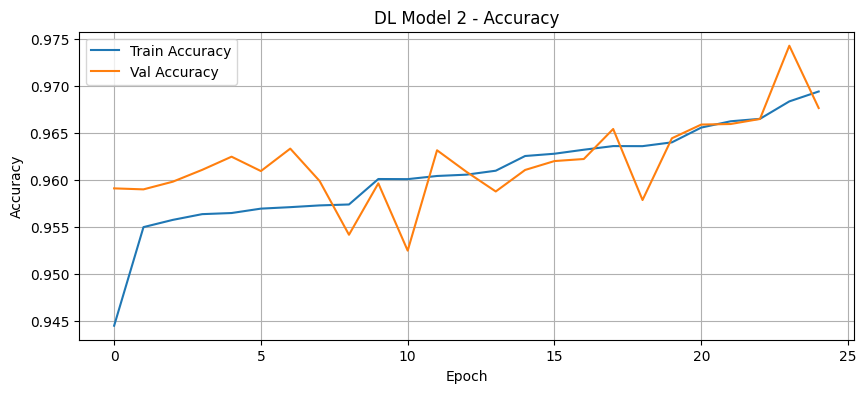

In [37]:
plt.figure(figsize=(10,4))
plt.plot(history_2.history['accuracy'], label='Train Accuracy')
plt.plot(history_2.history['val_accuracy'], label='Val Accuracy')
plt.title('DL Model 2 - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [38]:
y_prob_2 = dl_model_2.predict(x_test_final_scaled).ravel()
y_pred_2 = (y_prob_2 >= 0.5).astype(int)

print("DL Model 2 Accuracy:", accuracy_score(y_test_, y_pred_2))
print("DL Model 2 ROC-AUC :", roc_auc_score(y_test_, y_prob_2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_, y_pred_2))
print("\nClassification Report:\n", classification_report(y_test_, y_pred_2))

7954/7954 ━━━━━━━━━━━━━━━━━━━━ 5s 602us/step
DL Model 2 Accuracy: 0.9679226749440101
DL Model 2 ROC-AUC : 0.9978652850022518

Confusion Matrix:
 [[196749   7670]
 [   494  49597]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98    204419
           1       0.87      0.99      0.92     50091

    accuracy                           0.97    254510
   macro avg       0.93      0.98      0.95    254510
weighted avg       0.97      0.97      0.97    254510



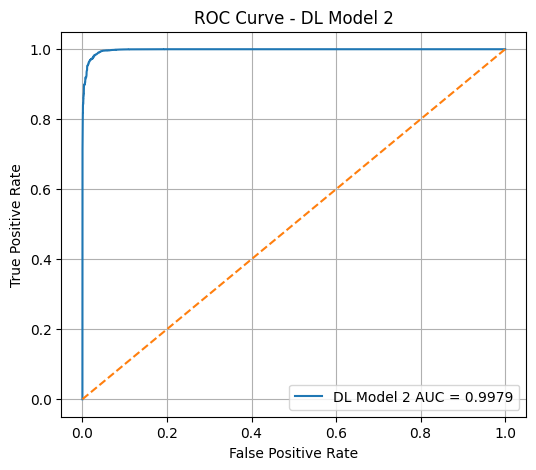

In [39]:
fpr2, tpr2, _ = roc_curve(y_test_, y_prob_2)

plt.figure(figsize=(6,5))
plt.plot(fpr2, tpr2, label=f'DL Model 2 AUC = {roc_auc_score(y_test_, y_prob_2):.4f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DL Model 2")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
results_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Random Forest-50 (depth=30)",
        "XGBoost-10",
        "XGBoost-50",
        "DL Model 1",
        "DL Model 2"
    ],
    "Accuracy": [
        0.9242282793706476,
        0.9989297047022269,
        0.9989179173090796,
        0.9957353211593137,
        0.9988943425227851,
        0.9679148167066127,
        accuracy_score(y_test_, y_pred_2)
    ]
})

results_summary

,Model,Accuracy
0,Logistic Regression,0.924228
1,Random Forest,0.998930
2,Random Forest-50 (depth=30),0.998918
3,XGBoost-10,0.995735
4,XGBoost-50,0.998894
5,DL Model 1,0.967915
6,DL Model 2,0.967923


The experimental results demonstrate that the XGB-50 classifier achieved the highest overall performance among all evaluated models with an accuracy exceeding 99.8% and near-perfect precision recall and F1-score for both classes. The model demonstrated its ability to accurately detect malicious network traffic through its performance which resulted in extremely few false negative results(156). The system requires this function to detect and prevent intrusions because security breaches occur when attacks go undetected.

The deep learning models showed better performance than ensemble methods but their results still fell short of the ensemble methods. The tabular structure of the CIC-IDS2017 dataset enables Random Forest and XGBoost ensemble models to effectively capture complex feature interactions while managing different types of data distribution. Deep neural networks need extensive parameter adjustment because their performance on structured tabular datasets depends on specialized design frameworks.

The XGB-50 model emerged as the ideal choice for deployment in the intrusion prevention system because it demonstrated optimal performance. The system can detect and prevent malicious network activity because its combination of high accuracy and strong performance with minimal false negative results enables it to do so.


In [41]:
dl_model_2.save("dl_model.h5")

In [ ]:
joblib.dump(xgb, "best_ids_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(x_train.columns.tolist(), "feature_names.pkl")
x_test.to_csv("x_test_final.csv", index=False)    #we save before scaling as we already have our scaler to be flexible
y_test.to_csv("y_test_final.csv", index=False)

In [ ]:
#saving the second DL model and it's scalar ,features and test data
dl_model_2.save("dl_model_2.keras")
joblib.dump(scaler, "dl_scaler.pkl")
joblib.dump(x_train.columns.tolist(), "dl_feature_names.pkl")
#save the test data of the DL second model
x_test_.to_csv("dl_x_test_final.csv", index=False)
y_test_.to_csv("dl_y_test_final.csv", index=False)

In [44]:
import pandas as pd
import numpy as np
import joblib
from keras.models import load_model

# load model files
model = load_model("dl_model.h5")
scaler = joblib.load("dl_scaler.pkl")
feature_names = joblib.load("dl_feature_names.pkl")

print("System Ready")



class IntrusionPreventionSystem:

    def __init__(self, model, scaler, feature_names,
                 alert_threshold=0.40, block_threshold=0.70):

        self.model = model
        self.scaler = scaler
        self.feature_names = feature_names
        self.alert_threshold = alert_threshold
        self.block_threshold = block_threshold

    def preprocess(self, df):
        df = df.copy()
        df.columns = df.columns.str.strip()

        # keep only the needed features
        df = df[self.feature_names]

        # convert to numerical
        df = df.apply(pd.to_numeric, errors='coerce')

        # clean values
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        df.dropna(inplace=True)

        # scaling
        df_scaled = self.scaler.transform(df)

        return df, df_scaled

    def decide(self, prob):
        if prob >= self.block_threshold:
            return "BLOCK"
        elif prob >= self.alert_threshold:
            return "ALERT"
        else:
            return "ALLOW"

    def response(self, action):
        if action == "ALLOW":
            return "Normal traffic"
        elif action == "ALERT":
            return "Suspicious traffic -> Monitor"
        elif action == "BLOCK":
            return "Malicious traffic -> Block immediately"

    def run(self, file_path):
        print(f"\nProcessing file: {file_path}")

        df = pd.read_csv(file_path)

        clean_df, scaled_df = self.preprocess(df)

        # flaten the output using .ravel()
        probs = self.model.predict(scaled_df).ravel()

        results = clean_df.copy()
        results["attack_probability"] = probs
        results["action"] = [self.decide(p) for p in probs]
        results["response"] = [self.response(a) for a in results["action"]]

        # save results
        results.to_csv("ips_output.csv", index=False)

        print("IPS RESULTS: ")
        print(results[["attack_probability", "action", "response"]].head())

        print("\nSaved to ips_output.csv")

        return results



file_path = "dl_x_test_final.csv"

ips = IntrusionPreventionSystem(model, scaler, feature_names)

ips.run(file_path)

System Ready

Processing file: dl_x_test_final.csv
7954/7954 ━━━━━━━━━━━━━━━━━━━━ 5s 611us/step
IPS RESULTS: 
   attack_probability action                                response
0            0.075210  ALLOW                          Normal traffic
1            0.000015  ALLOW                          Normal traffic
2            0.999997  BLOCK  Malicious traffic -> Block immediately
3            0.000009  ALLOW                          Normal traffic
4            0.000130  ALLOW                          Normal traffic

Saved to ips_output.csv


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,attack_probability,action,response
0,46,1,1,0,0,0,0,0.000000,0.000000,0,...,0.0,0,0,0.0,0.0,0,0,0.075210,ALLOW,Normal traffic
1,189,2,2,102,224,51,51,51.000000,0.000000,112,...,0.0,0,0,0.0,0.0,0,0,0.000015,ALLOW,Normal traffic
2,99962653,8,7,1077,11595,353,0,134.625000,180.848743,5792,...,0.0,14021,14021,99400000.0,0.0,99400000,99400000,0.999997,BLOCK,Malicious traffic -> Block immediately
3,30720,1,1,50,66,50,50,50.000000,0.000000,66,...,0.0,0,0,0.0,0.0,0,0,0.000009,ALLOW,Normal traffic
4,262695,6,6,356,3782,212,0,59.333333,89.224810,1460,...,0.0,0,0,0.0,0.0,0,0,0.000130,ALLOW,Normal traffic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254505,61471,2,2,82,114,41,41,41.000000,0.000000,57,...,0.0,0,0,0.0,0.0,0,0,0.000012,ALLOW,Normal traffic
254506,83916841,8,4,56,11601,20,0,7.000000,5.656854,10220,...,0.0,999,999,41000000.0,46900000.0,74200000,7825815,1.000000,BLOCK,Malicious traffic -> Block immediately
254507,61,2,0,31,0,31,0,15.500000,21.920310,0,...,0.0,0,0,0.0,0.0,0,0,0.000306,ALLOW,Normal traffic
254508,85095041,9,5,321,11595,321,0,35.666667,107.000000,10136,...,0.0,1014,1014,84900000.0,0.0,84900000,84900000,0.999999,BLOCK,Malicious traffic -> Block immediately


In [45]:
from sklearn.metrics import confusion_matrix, classification_report
#compare the predicted ips_output with dl_y_test_final.csv
dl_y_test_final = pd.read_csv("dl_y_test_final.csv")
ips_output = pd.read_csv("ips_output.csv")
#attack_probability = 1 if greater than 0.5
ips_output["attack_probability"] = ips_output["attack_probability"].apply(lambda x: 1 if x >= 0.5 else 0)
#get confusion matrix and classification report
print(confusion_matrix(dl_y_test_final, ips_output["attack_probability"]))
print(classification_report(dl_y_test_final, ips_output["attack_probability"]))

[[196749   7670]
 [   494  49597]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    204419
           1       0.87      0.99      0.92     50091

    accuracy                           0.97    254510
   macro avg       0.93      0.98      0.95    254510
weighted avg       0.97      0.97      0.97    254510

